In [8]:

import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)


In [9]:
# KERAS

keras_model = Sequential([
    Dense(4, input_dim=2, activation='tanh'),
    Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

keras_history = keras_model.fit(X, y, epochs=150, verbose=0)
keras_preds = keras_model.predict(X)

# PYTORCH
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.h = nn.Linear(2,4)
        self.o = nn.Linear(4,1)
    def forward(self,x):
        return torch.sigmoid(self.o(torch.tanh(self.h(x))))

torch_model = XORNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.1)

torch_losses = []
for _ in range(150):
    optimizer.zero_grad()
    out = torch_model(X_torch)
    loss = criterion(out, y_torch)
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())

torch_preds = torch_model(X_torch).detach().numpy()

# TENSORFLOW LOW LEVEL
W1 = tf.Variable(tf.random.normal([2,4]))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4,1]))
b2 = tf.Variable(tf.zeros([1]))

def tf_model(x):
    h = tf.nn.tanh(tf.matmul(x, W1) + b1)
    return tf.nn.sigmoid(tf.matmul(h, W2) + b2)

optimizer = tf.keras.optimizers.Adam(0.1)
loss_fn = tf.keras.losses.BinaryCrossentropy()

X_tf = tf.constant(X, tf.float32)
y_tf = tf.constant(y, tf.float32)

tf_losses = []
for _ in range(150):
    with tf.GradientTape() as tape:
        preds = tf_model(X_tf)
        loss = loss_fn(y_tf, preds)
    grads = tape.gradient(loss, [W1,b1,W2,b2])
    optimizer.apply_gradients(zip(grads,[W1,b1,W2,b2]))
    tf_losses.append(loss.numpy())

tf_preds = tf_model(X_tf).numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


Final Accuracy
Keras: 1.0
PyTorch: 1.0
TensorFlow: 1.0


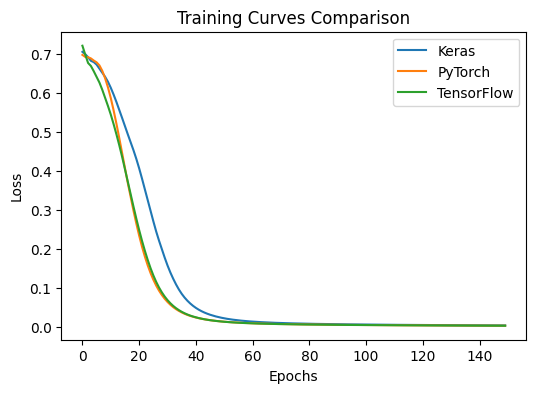

In [10]:
# ACCURACY
def acc(y, p):
    return np.mean(y == np.round(p))

print("Final Accuracy")
print("Keras:", acc(y, keras_preds))
print("PyTorch:", acc(y, torch_preds))
print("TensorFlow:", acc(y, tf_preds))

# TRAINING CURVES
plt.figure(figsize=(6,4))
plt.plot(keras_history.history['loss'], label="Keras")
plt.plot(torch_losses, label="PyTorch")
plt.plot(tf_losses, label="TensorFlow")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Curves Comparison")
plt.legend()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


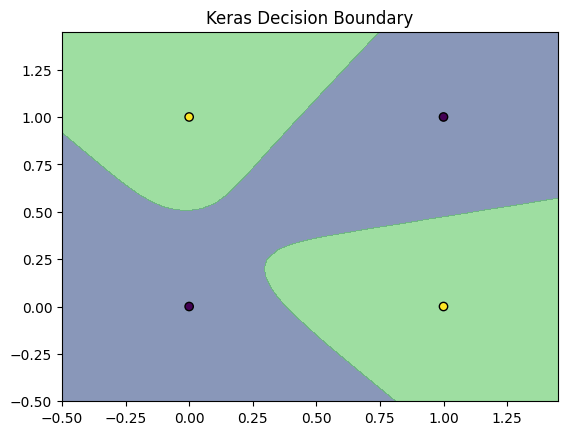

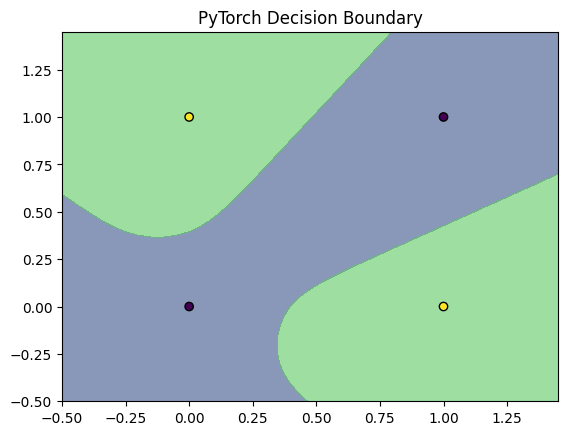

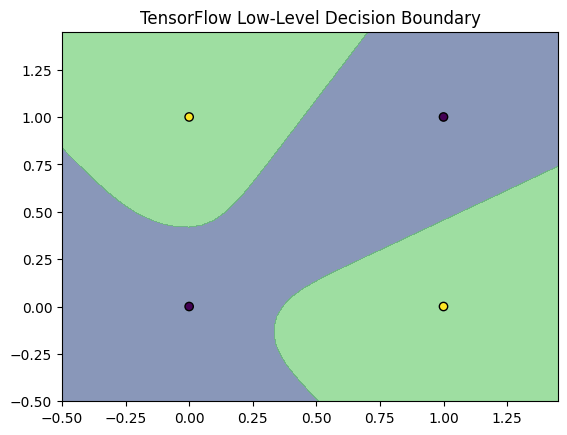

In [11]:

# DECISION BOUNDARIES
def mesh(step=0.05):
    xx, yy = np.meshgrid(
        np.arange(-0.5,1.5,step),
        np.arange(-0.5,1.5,step))
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]

xx, yy, grid = mesh()

# KERAS DECISION BOUNDARY
Z = keras_model.predict(grid).reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[0,0.5,1], alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.title("Keras Decision Boundary")
plt.show()

# PYTORCH DECISION BOUNDARY
Z = torch_model(torch.tensor(grid, dtype=torch.float32)).detach().numpy().reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[0,0.5,1], alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.title("PyTorch Decision Boundary")
plt.show()

# TENSORFLOW LOW-LEVEL DECISION BOUNDARY
Z = tf_model(tf.constant(grid, dtype=tf.float32)).numpy().reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[0,0.5,1], alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y.flatten(), edgecolors='k')
plt.title("TensorFlow Low-Level Decision Boundary")
plt.show()

## Interpretation of Results and Hyperparameter Discussion

### Results from the XOR Example

Following observations are made based on the results:

*   **Final Accuracy:** All three implementations (Keras, PyTorch, and TensorFlow Low-Level) achieved a final accuracy of **1.0**. This means that each model successfully learned the XOR logic, correctly classifying all four input patterns.
*   **Training Curves Comparison:** The training curves show that the loss for all three models decreased significantly and converged to near zero within the 150 epochs. This indicates that the models were able to effectively learn from the training data and minimize the binary cross-entropy loss. The curves illustrate the learning process, showing how the models gradually improved their predictions over time.
*   **Decision Boundaries:** The decision boundary plots visually confirm that each model successfully separated the input space according to the XOR function. The regions are clearly defined, indicating that the models have learned the non-linear relationship between the inputs and outputs.

### Discussion on Hyperparameter Effects

Hyperparameters are crucial for neural network performance.
These are some of them which affect the learning:

1.  **Learning Rate:** Controls the step size of weight updates. A **high learning rate** can lead to overshooting or instability, while a **very low learning rate** can make training slow or trap the model in local minima.

2.  **Activation Function:** Introduces non-linearity, allowing the network to learn complex patterns. Without non-linear activations (like `tanh` or `sigmoid` used here), a multi-layer network behaves like a single-layer one. Different activations affect convergence and model capacity.

3.  **Hidden Layers (Number and Size):** Determine the network's capacity to learn complex mappings. Too many can lead to overfitting, too few to underfitting. For XOR, a single hidden layer with a few neurons is sufficient.

4.  **Epochs:** The number of full passes through the training data. **Too few epochs** result in underfitting (model hasn't learned enough), while **too many** can cause overfitting (model learns noise in the training data).